# PROYECTO ABP - MÓDULO 5  
## ComercioYA - Análisis Exploratorio y Modelado  
**Autora:** Joselyn Mena Castillo


## Introducción

En el presente proyecto ABP del Módulo 5 se busca aplicar técnicas de análisis exploratorio de datos, correlación, regresión lineal y visualización avanzada para extraer conclusiones relevantes a partir de un conjunto de datos.

Dado que no se proporcionó un dataset específico para el desarrollo del proyecto, se decidió diseñar y generar un conjunto de datos sintético desde cero utilizando Python, particularmente las librerías **NumPy** y **Pandas**. 

El dataset fue construido de manera estratégica para simular el comportamiento de clientes de una empresa ficticia de comercio electrónico llamada *ComercioYA*. Se modelaron variables demográficas, de comportamiento digital y comerciales, incorporando relaciones lógicas entre ellas (por ejemplo, mayor número de visitas asociado a mayor número de compras), lo que permite aplicar técnicas de correlación y regresión de forma coherente y realista.

La generación controlada del dataset asegura que el análisis no sea arbitrario, sino que esté fundamentado en supuestos consistentes con un contexto empresarial, permitiendo desarrollar un análisis estadístico completo y técnicamente sólido.

## Objetivo del análisis

El objetivo principal de este proyecto es analizar el comportamiento de compra de los clientes de ComercioYA mediante técnicas de análisis exploratorio de datos, correlación y regresión lineal.

Se busca:

- Describir estadísticamente el conjunto de datos.
- Identificar relaciones entre variables clave.
- Modelar el gasto total a través de regresión lineal.
- Extraer conclusiones apoyadas en visualización de datos.

## 1. Creación del dataset

Dado que no se proporcionó un dataset específico, se generó un conjunto de datos sintético utilizando NumPy y Pandas. 

El dataset simula el comportamiento de clientes de una empresa de comercio electrónico, incorporando relaciones lógicas entre variables para permitir un análisis estadístico coherente.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Configuración estética
sns.set(style="whitegrid")
np.random.seed(2024)

In [39]:
# Tamaño del dataset
n = 400

# ------------------------
# Variables demográficas
# ------------------------
edad = np.random.randint(18, 70, n)
ingreso_mensual = np.random.normal(800000, 250000, n)

segmento_cliente = np.random.choice(
    ["Basico", "Premium", "VIP"],
    size=n,
    p=[0.5, 0.35, 0.15]
)

# ------------------------
#  Comportamiento digital
# ------------------------
visitas_mensuales = np.random.poisson(10, n)
tiempo_promedio_sesion = np.random.normal(8, 2, n)
clicks_promociones = np.random.poisson(4, n)
uso_cupon = np.random.binomial(1, 0.45, n)

# ------------------------
#  Variables comerciales
# ------------------------
numero_compras = (
    visitas_mensuales * 0.4 +
    uso_cupon * 2 +
    np.random.normal(1, 1, n)
)

monto_promedio_compra = (
    ingreso_mensual * 0.002 +
    np.random.normal(20000, 5000, n)
)

gasto_total = (
    numero_compras * monto_promedio_compra +
    np.random.normal(0, 30000, n)
)

devoluciones = np.random.poisson(1, n)

rating_cliente = np.clip(
    5 - devoluciones * 0.5 + np.random.normal(0, 0.3, n),
    1,
    5
)

# ------------------------
#     Crear DataFrame
# ------------------------
df = pd.DataFrame({
    "edad": edad,
    "ingreso_mensual": ingreso_mensual,
    "segmento_cliente": segmento_cliente,
    "visitas_mensuales": visitas_mensuales,
    "tiempo_promedio_sesion": tiempo_promedio_sesion,
    "clicks_promociones": clicks_promociones,
    "uso_cupon": uso_cupon,
    "numero_compras": numero_compras,
    "monto_promedio_compra": monto_promedio_compra,
    "gasto_total": gasto_total,
    "devoluciones": devoluciones,
    "rating_cliente": rating_cliente
})

df.head()

,edad,ingreso_mensual,segmento_cliente,visitas_mensuales,tiempo_promedio_sesion,clicks_promociones,uso_cupon,numero_compras,monto_promedio_compra,gasto_total,devoluciones,rating_cliente
0,26,6.934394e+05,VIP,11,7.371693,7,1,7.131900,22802.063483,187085.590788,2,3.641221
1,50,1.049158e+06,Premium,15,8.521245,4,0,6.801682,19243.554915,138988.035055,1,4.481090
2,18,1.072337e+06,Basico,10,8.327247,3,0,6.278786,20720.765752,151568.521192,0,4.689187
3,45,-3.265797e+04,Premium,12,6.637087,2,1,9.339645,16145.513275,127105.396604,1,4.874675
4,54,9.287955e+05,VIP,5,10.454121,8,0,2.871910,24928.690386,50934.490201,2,3.798768


## 2. Revisión inicial del dataset

Se analiza la estructura, tipos de datos, valores nulos y estadísticas descriptivas para comprender la composición del conjunto de datos.

In [40]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   edad                    400 non-null    int32  
 1   ingreso_mensual         400 non-null    float64
 2   segmento_cliente        400 non-null    str    
 3   visitas_mensuales       400 non-null    int32  
 4   tiempo_promedio_sesion  400 non-null    float64
 5   clicks_promociones      400 non-null    int32  
 6   uso_cupon               400 non-null    int32  
 7   numero_compras          400 non-null    float64
 8   monto_promedio_compra   400 non-null    float64
 9   gasto_total             400 non-null    float64
 10  devoluciones            400 non-null    int32  
 11  rating_cliente          400 non-null    float64
dtypes: float64(6), int32(5), str(1)
memory usage: 29.8 KB


In [41]:
df.describe()

,edad,ingreso_mensual,visitas_mensuales,tiempo_promedio_sesion,clicks_promociones,uso_cupon,numero_compras,monto_promedio_compra,gasto_total,devoluciones,rating_cliente
count,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,42.985000,7.909679e+05,10.115000,7.951135,4.017500,0.475,6.017168,21556.597872,130466.188697,1.045000,4.429485
std,14.503298,2.642077e+05,3.020693,2.076785,1.976603,0.500,1.841509,4714.371341,58946.853496,1.056298,0.553647
min,18.000000,-5.518390e+04,2.000000,2.958502,0.000000,0.000,0.460817,4878.749143,-23055.349146,0.000000,1.978038
25%,31.000000,6.215340e+05,8.000000,6.441366,3.000000,0.000,4.712347,18342.024553,85962.169471,0.000000,4.079634
50%,43.000000,7.829958e+05,10.000000,7.864812,4.000000,0.000,6.031139,22078.579531,130397.399014,1.000000,4.541602
75%,55.000000,9.657235e+05,12.000000,9.448242,5.000000,1.000,7.105099,25037.971680,170249.149961,2.000000,4.917567
max,69.000000,1.694034e+06,20.000000,13.522836,11.000000,1.000,12.388347,35624.070757,297740.012656,7.000000,5.000000


In [42]:
df.isnull().sum()

edad                      0
ingreso_mensual           0
segmento_cliente          0
visitas_mensuales         0
tiempo_promedio_sesion    0
clicks_promociones        0
uso_cupon                 0
numero_compras            0
monto_promedio_compra     0
gasto_total               0
devoluciones              0
rating_cliente            0
dtype: int64

## 3. Hipótesis iniciales

Antes de realizar el análisis exploratorio y el modelado, se plantean las siguientes hipótesis basadas en la lógica del negocio:

1. Un mayor número de visitas mensuales está asociado a un mayor número de compras.
2. Los clientes con mayor ingreso mensual tienden a presentar un mayor gasto total.
3. El uso de cupones podría aumentar el número de compras realizadas.
4. Un mayor número de devoluciones podría impactar negativamente en el rating del cliente.
5. Los clientes del segmento VIP podrían presentar un gasto total superior al resto de los segmentos.

Estas hipótesis serán evaluadas mediante análisis estadístico descriptivo, visualización de datos y modelos de regresión lineal.

## 4. Análisis Exploratorio de Datos (EDA)

En esta sección se analiza la distribución y comportamiento de las variables del dataset, comenzando por variables demográficas, luego comportamiento digital y finalmente variables comerciales.

### 4.1 Variables Demográficas

Se analizan las variables edad, ingreso_mensual y segmento_cliente para comprender la composición de la base de clientes.

#### 4.1.1 Edad - Histograma

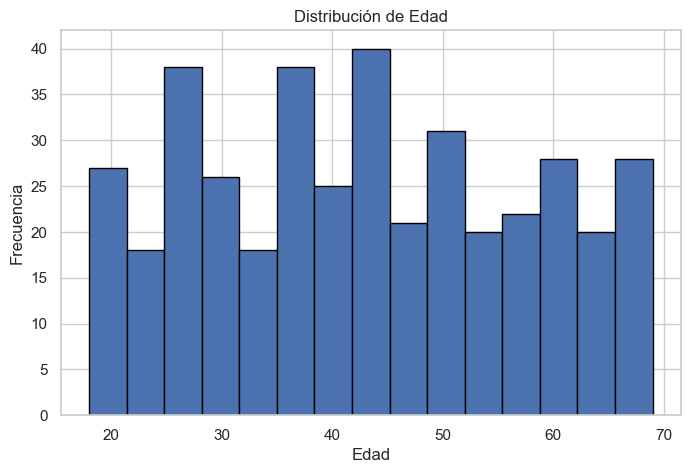

In [43]:
plt.figure(figsize=(8,5))
plt.hist(df["edad"], bins=15, color="#4C72B0", edgecolor="black")
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

#### 4.1.2 Ingreso Mensual - Histograma

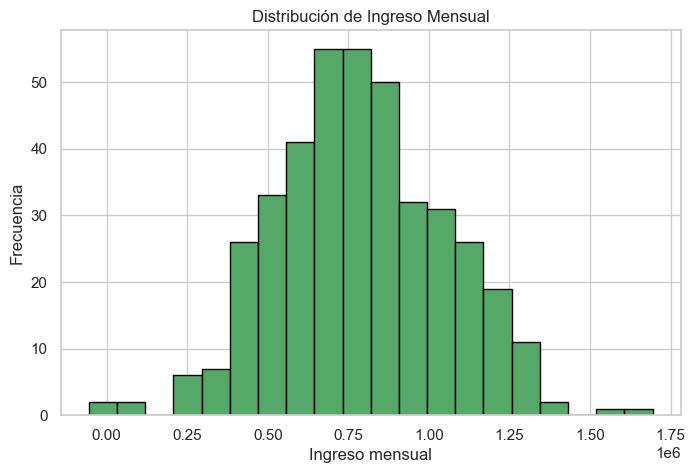

In [44]:
plt.figure(figsize=(8,5))
plt.hist(df["ingreso_mensual"], bins=20, color="#55A868", edgecolor="black")
plt.title("Distribución de Ingreso Mensual")
plt.xlabel("Ingreso mensual")
plt.ylabel("Frecuencia")
plt.show()

#### 4.1.3 Segmento Cliente - Barras

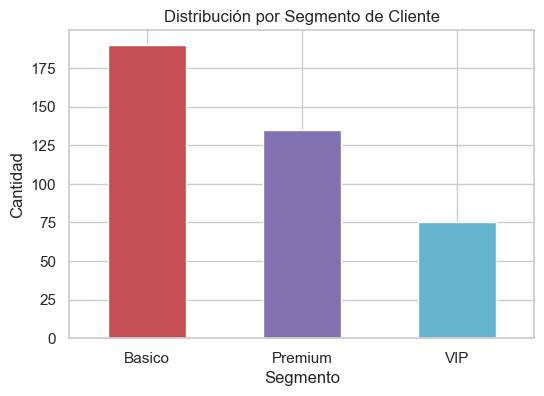

In [45]:
plt.figure(figsize=(6,4))
df["segmento_cliente"].value_counts().plot(kind="bar", color=["#C44E52","#8172B2","#64B5CD"])
plt.title("Distribución por Segmento de Cliente")
plt.xlabel("Segmento")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

#### Hallazgos iniciales

- La variable edad presenta una distribución relativamente uniforme entre 18 y 70 años, sin concentración marcada en un rango específico ni presencia evidente de valores atípicos.

- El ingreso mensual muestra una distribución aproximadamente normal, con mayor concentración entre 600.000 y 1.000.000. Se observan algunos valores extremos que podrían influir en el análisis del gasto total.

- El segmento Básico representa la mayor proporción de clientes, seguido por Premium y luego VIP. Esta composición podría impactar los niveles promedio de gasto y será relevante al comparar comportamientos entre segmentos.

### 4.2 Comportamiento Digital

En esta sección se analizan las variables relacionadas con la interacción digital de los clientes: visitas_mensuales, tiempo_promedio_sesion, clicks_promociones y uso_cupon.

#### 4.2.1 Visitas Mensuales - Histograma

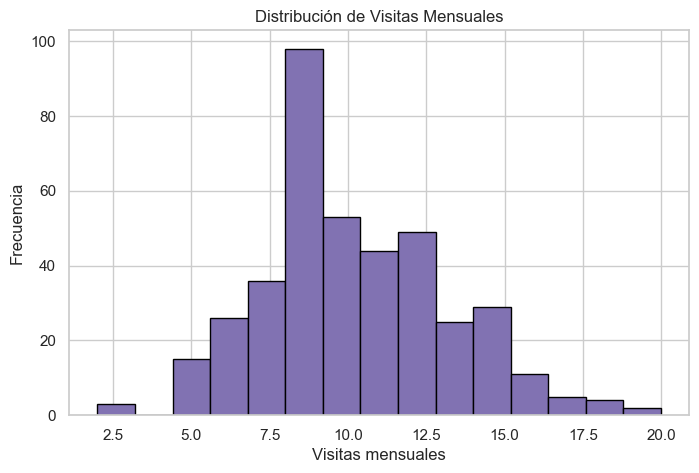

In [46]:
plt.figure(figsize=(8,5))
plt.hist(df["visitas_mensuales"], bins=15, color="#8172B2", edgecolor="black")
plt.title("Distribución de Visitas Mensuales")
plt.xlabel("Visitas mensuales")
plt.ylabel("Frecuencia")
plt.show()

#### 4.2.2 Tiempo Promedio de Sesión - Histograma

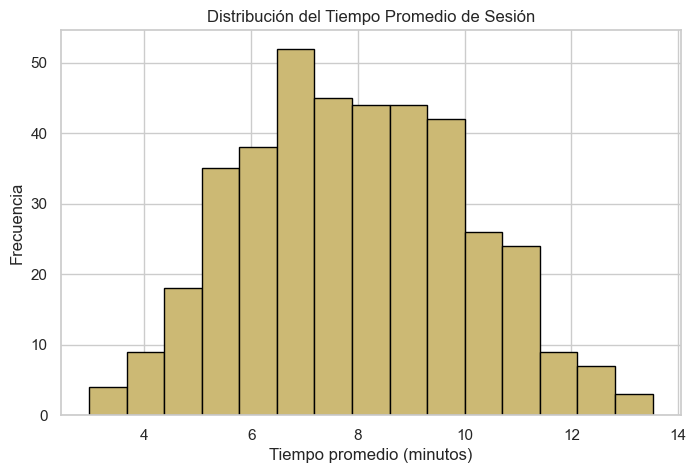

In [47]:
plt.figure(figsize=(8,5))
plt.hist(df["tiempo_promedio_sesion"], bins=15, color="#CCB974", edgecolor="black")
plt.title("Distribución del Tiempo Promedio de Sesión")
plt.xlabel("Tiempo promedio (minutos)")
plt.ylabel("Frecuencia")
plt.show()

#### 4.2.3 Clicks en Promociones - Histograma

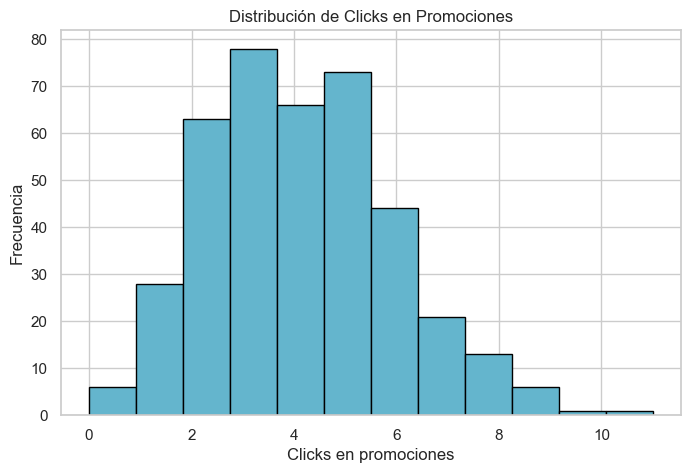

In [48]:
plt.figure(figsize=(8,5))
plt.hist(df["clicks_promociones"], bins=12, color="#64B5CD", edgecolor="black")
plt.title("Distribución de Clicks en Promociones")
plt.xlabel("Clicks en promociones")
plt.ylabel("Frecuencia")
plt.show()

#### 4.2.4 Uso de Cupón - Barras

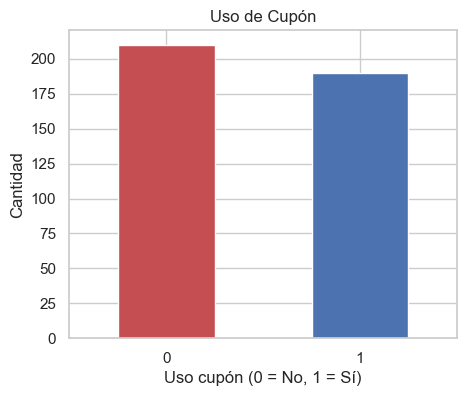

In [49]:
plt.figure(figsize=(5,4))
df["uso_cupon"].value_counts().plot(kind="bar", color=["#C44E52","#4C72B0"])
plt.title("Uso de Cupón")
plt.xlabel("Uso cupón (0 = No, 1 = Sí)")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

### Hallazgos sobre comportamiento digital

- Las visitas mensuales presentan una distribución concentrada entre 8 y 12 visitas, con ligera asimetría hacia valores altos, lo que indica una interacción moderada y constante de la mayoría de los clientes.

- El tiempo promedio de sesión muestra una distribución aproximadamente normal centrada en torno a los 8 minutos, sin presencia de valores atípicos significativos.

- Los clicks en promociones presentan variabilidad moderada, con mayor concentración entre 2 y 6 clicks, lo que sugiere interés en ofertas pero sin comportamientos extremos.

- El uso de cupón se distribuye de manera relativamente equilibrada entre clientes que utilizan y no utilizan descuentos, lo que permitirá evaluar su impacto en variables comerciales posteriores.

### 4.3 Variables Comerciales

En esta sección se analizan las variables directamente asociadas al comportamiento de compra de los clientes: numero_compras, gasto_total y rating.

#### 4.3.1 Número de Compras - Histograma

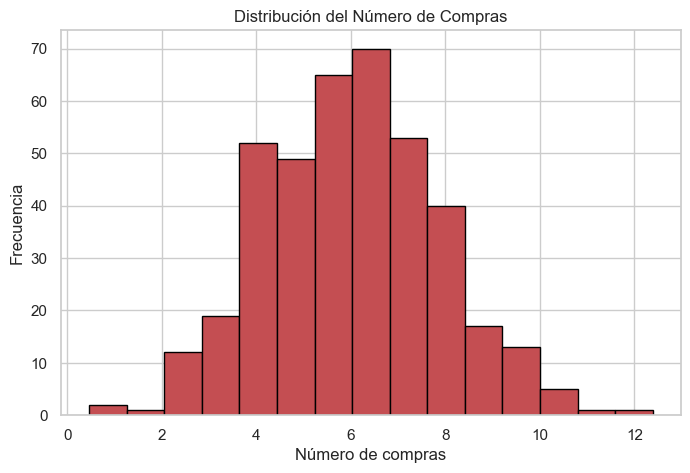

In [50]:
plt.figure(figsize=(8,5))
plt.hist(df["numero_compras"], bins=15, color="#C44E52", edgecolor="black")
plt.title("Distribución del Número de Compras")
plt.xlabel("Número de compras")
plt.ylabel("Frecuencia")
plt.show()

#### 4.3.2 Gasto Total - Histograma

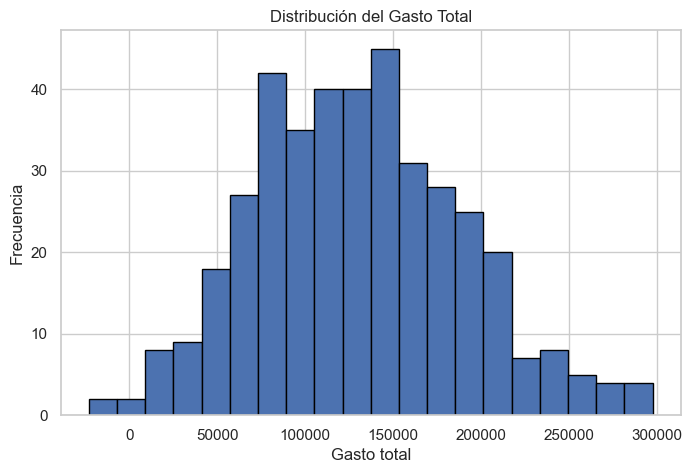

In [51]:
plt.figure(figsize=(8,5))
plt.hist(df["gasto_total"], bins=20, color="#4C72B0", edgecolor="black")
plt.title("Distribución del Gasto Total")
plt.xlabel("Gasto total")
plt.ylabel("Frecuencia")
plt.show()

#### 4.3.3 Rating Cliente - Histograma

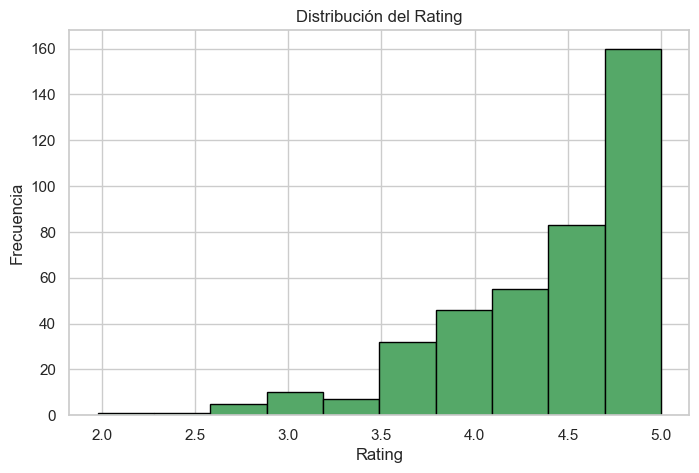

In [52]:
plt.figure(figsize=(8,5))
plt.hist(df["rating_cliente"], bins=10, color="#55A868", edgecolor="black")
plt.title("Distribución del Rating")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")
plt.show()

### Hallazgos sobre variables comerciales

- El número de compras presenta una distribución aproximadamente normal centrada entre 5 y 7 compras, lo que indica un comportamiento relativamente homogéneo entre los clientes.

- El gasto total muestra ligera asimetría positiva, con presencia de clientes de mayor valor económico, lo que sugiere oportunidades de segmentación basada en valor.

- El rating_cliente se concentra mayoritariamente entre 4.0 y 5.0, evidenciando un alto nivel de satisfacción general, aunque con limitada variabilidad en valores bajos.

### 4.4 Estadística Descriptiva

En esta sección se calculan medidas de tendencia central, dispersión y posición para comprender la distribución de las variables numéricas del dataset.

#### 4.4.1 Resumen general

In [53]:
df.describe()

,edad,ingreso_mensual,visitas_mensuales,tiempo_promedio_sesion,clicks_promociones,uso_cupon,numero_compras,monto_promedio_compra,gasto_total,devoluciones,rating_cliente
count,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,42.985000,7.909679e+05,10.115000,7.951135,4.017500,0.475,6.017168,21556.597872,130466.188697,1.045000,4.429485
std,14.503298,2.642077e+05,3.020693,2.076785,1.976603,0.500,1.841509,4714.371341,58946.853496,1.056298,0.553647
min,18.000000,-5.518390e+04,2.000000,2.958502,0.000000,0.000,0.460817,4878.749143,-23055.349146,0.000000,1.978038
25%,31.000000,6.215340e+05,8.000000,6.441366,3.000000,0.000,4.712347,18342.024553,85962.169471,0.000000,4.079634
50%,43.000000,7.829958e+05,10.000000,7.864812,4.000000,0.000,6.031139,22078.579531,130397.399014,1.000000,4.541602
75%,55.000000,9.657235e+05,12.000000,9.448242,5.000000,1.000,7.105099,25037.971680,170249.149961,2.000000,4.917567
max,69.000000,1.694034e+06,20.000000,13.522836,11.000000,1.000,12.388347,35624.070757,297740.012656,7.000000,5.000000


#### 4.4.2 Media, Mediana, Varianza y Desviación Estándar

In [54]:
estadisticas = df[[
    "edad",
    "ingreso_mensual",
    "visitas_mensuales",
    "tiempo_promedio_sesion",
    "clicks_promociones",
    "numero_compras",
    "gasto_total",
    "rating_cliente"
]].agg(["mean", "median", "var", "std"])

estadisticas

,edad,ingreso_mensual,visitas_mensuales,tiempo_promedio_sesion,clicks_promociones,numero_compras,gasto_total,rating_cliente
mean,42.985000,7.909679e+05,10.115000,7.951135,4.017500,6.017168,1.304662e+05,4.429485
median,43.000000,7.829958e+05,10.000000,7.864812,4.000000,6.031139,1.303974e+05,4.541602
var,210.345639,6.980569e+10,9.124586,4.313038,3.906961,3.391154,3.474732e+09,0.306525
std,14.503298,2.642077e+05,3.020693,2.076785,1.976603,1.841509,5.894685e+04,0.553647


#### 4.4.3 Moda (para variables categóricas)

In [55]:
df["segmento_cliente"].mode()


0    Basico
Name: segmento_cliente, dtype: str

In [56]:
df["uso_cupon"].mode()

0    0
Name: uso_cupon, dtype: int32

#### 4.4.4 Cuartiles y Percentiles

In [57]:
df[[
    "numero_compras",
    "gasto_total",
    "visitas_mensuales"
]].quantile([0.25, 0.5, 0.75, 0.90])

,numero_compras,gasto_total,visitas_mensuales
0.25,4.712347,85962.169471,8.0
0.50,6.031139,130397.399014,10.0
0.75,7.105099,170249.149961,12.0
0.90,8.312525,205444.899768,14.0


### Interpretación de la Estadística Descriptiva

El análisis de las medidas de tendencia central muestra que las variables demográficas, como la edad, presentan una distribución relativamente simétrica, evidenciada por la cercanía entre la media y la mediana.

En el caso del ingreso mensual, se observa una dispersión considerable, reflejada en su desviación estándar elevada, lo que indica variabilidad económica entre los clientes.

Las variables de comportamiento digital, como visitas_mensuales y numero_compras, presentan baja dispersión y valores centrales muy cercanos entre media y mediana, lo que sugiere un comportamiento relativamente homogéneo en la frecuencia de interacción y compra.

El gasto_total muestra una variabilidad importante. El percentil 90 indica que el 10% de los clientes realiza gastos considerablemente superiores al promedio, lo que sugiere la existencia de un segmento de alto valor comercial.

El rating_cliente presenta una media alta y baja desviación estándar, lo que indica que la satisfacción general es elevada y relativamente estable entre los clientes.

Respecto a las variables categóricas, la moda de uso_cupon es 0, lo que indica que la mayoría de los clientes no utiliza cupones en sus compras.

### 4.5 Análisis de Outliers

En esta sección se identifican posibles valores atípicos en las variables numéricas mediante el método del rango intercuartílico (IQR).

In [58]:
variables_numericas = [
    "numero_compras",
    "gasto_total",
    "visitas_mensuales",
    "ingreso_mensual"
]

for col in variables_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    
    print(f"{col}: {len(outliers)} outliers detectados")

numero_compras: 4 outliers detectados
gasto_total: 1 outliers detectados
visitas_mensuales: 2 outliers detectados
ingreso_mensual: 6 outliers detectados


### Interpretación del Análisis de Outliers

El análisis mediante el método del rango intercuartílico (IQR) permitió identificar una cantidad reducida de valores atípicos en las principales variables numéricas del dataset.

Se detectaron:

- 4 outliers en numero_compras
- 1 outlier en gasto_total
- 2 outliers en visitas_mensuales
- 6 outliers en ingreso_mensual

La proporción de valores atípicos es baja en relación con el total de observaciones (400 registros), lo que indica que no representan un problema estructural en los datos.

En el caso de ingreso_mensual, la presencia de algunos valores extremos es coherente con la variabilidad natural de ingresos en una población.

Dado que los outliers detectados pueden corresponder a comportamientos reales (clientes de alto gasto o altos ingresos), no se procederá a su eliminación, ya que podrían aportar información relevante para el análisis posterior y la construcción de modelos predictivos.

### 4.6 Análisis de Correlación

Se analiza la relación entre variables numéricas para identificar posibles asociaciones entre comportamiento digital y desempeño comercial.

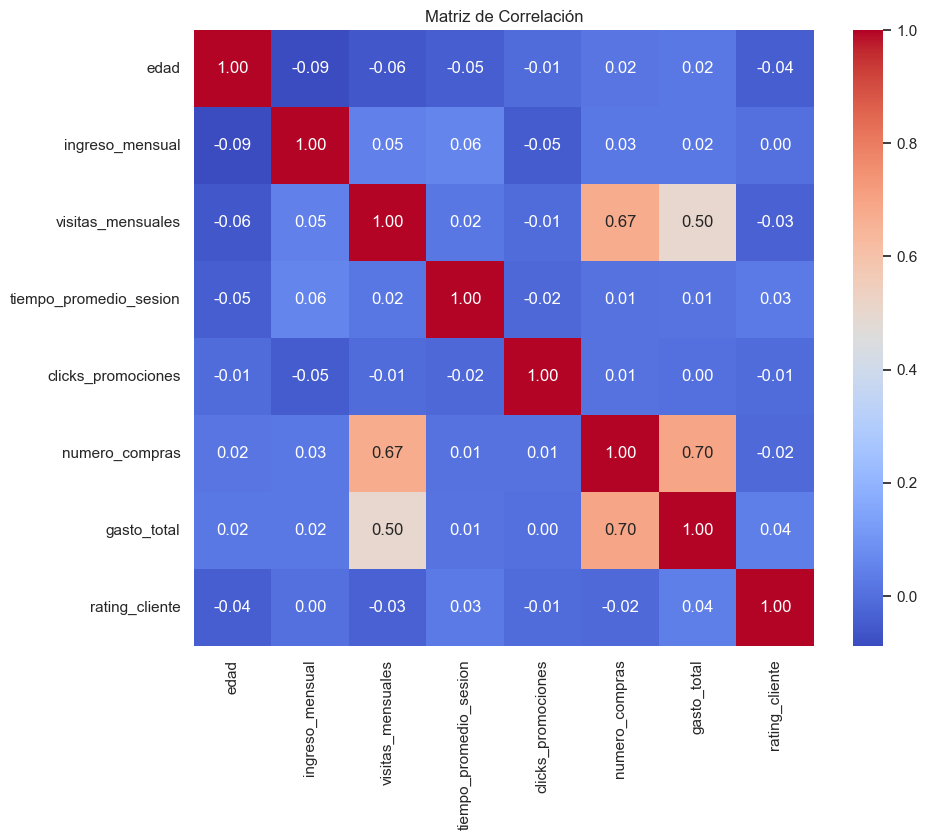

In [59]:
import seaborn as sns
import numpy as np

# Selección de variables numéricas
variables_numericas = df[[
    "edad",
    "ingreso_mensual",
    "visitas_mensuales",
    "tiempo_promedio_sesion",
    "clicks_promociones",
    "numero_compras",
    "gasto_total",
    "rating_cliente"
]]

# Matriz de correlación
corr = variables_numericas.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

### Hallazgos de correlación

- Existe una correlación fuerte (0.70) entre numero_compras y gasto_total, indicando que el gasto está principalmente explicado por la frecuencia de compra.

- Las visitas_mensuales presentan correlación fuerte con numero_compras (0.67) y moderada con gasto_total (0.50), lo que sugiere que la interacción digital impacta indirectamente en el desempeño comercial.

- Las variables demográficas (edad, ingreso_mensual) muestran correlaciones muy bajas con variables comerciales, indicando que el comportamiento digital tiene mayor peso que las características demográficas en este dataset.

- rating_cliente presenta baja correlación con el resto de variables, posiblemente debido a su concentración en valores altos.

### 4.7 Regresión Lineal Simple

#### 4.7.1 Modelo 1: Gasto Total vs Número de Compras

Se construye un modelo de regresión lineal simple para analizar el impacto del número de compras sobre el gasto total de los clientes.

In [60]:
X = df["numero_compras"]
y = df["gasto_total"]

# Agregamos constante
X = sm.add_constant(X)

modelo_simple = sm.OLS(y, X).fit()

print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:            gasto_total   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     375.4
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.22e-59
Time:                        22:32:32   Log-Likelihood:                -4828.0
No. Observations:                 400   AIC:                             9660.
Df Residuals:                     398   BIC:                             9668.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -3720.7934   7242.439     -0.

#### Interpretación del Modelo de Regresión Lineal Simple

Se construyó un modelo de regresión lineal simple para evaluar el impacto del número de compras sobre el gasto total.

El modelo obtuvo un R² de 0.485, lo que indica que aproximadamente el 48.5% de la variabilidad del gasto_total es explicada por la variable numero_compras.

El coeficiente estimado para numero_compras es aproximadamente 22.300, lo que significa que, en promedio, cada compra adicional incrementa el gasto total en aproximadamente 22.300 unidades monetarias.

El p-value asociado a numero_compras es menor a 0.001, lo que indica que la relación es estadísticamente significativa. Por lo tanto, se rechaza la hipótesis nula y se concluye que el número de compras tiene un efecto positivo y significativo sobre el gasto total.

Estos resultados confirman la fuerte asociación observada previamente en el análisis de correlación.

#### Visualización del Modelo de Regresión Lineal
Se presenta la relación entre el número de compras y el gasto total junto con la recta estimada por el modelo.

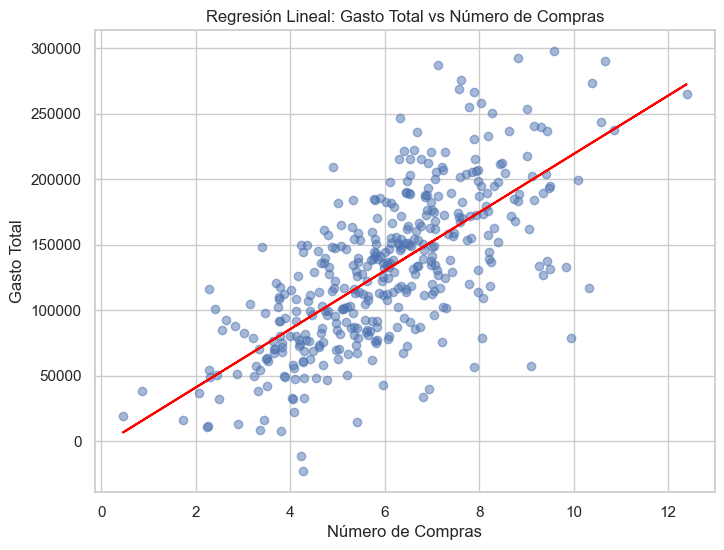

In [61]:
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(df["numero_compras"], df["gasto_total"], alpha=0.5)

# Línea de regresión
x_vals = df["numero_compras"]
y_vals = modelo_simple.predict(sm.add_constant(x_vals))

plt.plot(x_vals, y_vals, color="red")

plt.xlabel("Número de Compras")
plt.ylabel("Gasto Total")
plt.title("Regresión Lineal: Gasto Total vs Número de Compras")

plt.show()

La visualización confirma la relación positiva entre el número de compras y el gasto total. 
Se observa una tendencia creciente consistente con los resultados estadísticos del modelo, evidenciando que a mayor frecuencia de compra, mayor es el gasto acumulado del cliente.

## 4.8 Regresión Lineal Múltiple

### Modelo 2: Impacto conjunto de variables de comportamiento

Se construye un modelo de regresión lineal múltiple para analizar el efecto conjunto del número de compras, visitas mensuales y uso de cupón sobre el gasto total.

In [62]:
X_multi = df[["numero_compras", "visitas_mensuales", "uso_cupon"]]
y_multi = df["gasto_total"]

X_multi = sm.add_constant(X_multi)

modelo_multiple = sm.OLS(y_multi, X_multi).fit()

print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:            gasto_total   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     127.1
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.17e-57
Time:                        22:32:32   Log-Likelihood:                -4826.0
No. Observations:                 400   AIC:                             9660.
Df Residuals:                     396   BIC:                             9676.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -8052.2890   7938.32

### Interpretación del Modelo de Regresión Lineal Múltiple

Se construyó un modelo de regresión lineal múltiple para evaluar el impacto conjunto del número de compras, visitas mensuales y uso de cupón sobre el gasto total.

El modelo obtuvo un R² de 0.490, lo que representa un leve incremento respecto al modelo simple (0.485). Esto indica que las variables adicionales aportan escaso poder explicativo adicional.

La variable numero_compras continúa siendo altamente significativa (p < 0.001), confirmando que es el principal determinante del gasto total.

La variable visitas_mensuales presenta un nivel de significancia marginal (p = 0.060), lo que sugiere un efecto débil o condicionado.

Por otro lado, uso_cupon no resulta estadísticamente significativa (p = 0.120), lo que indica que, controlando por número de compras, el uso de cupones no tiene un impacto relevante sobre el gasto total.

En conclusión, el comportamiento de compra (frecuencia) es el factor más determinante del gasto, por sobre las variables promocionales analizadas.

### Modelo 3: Incorporando Ingreso Mensual
Se amplía el modelo incluyendo ingreso_mensual como variable explicativa adicional.

In [63]:
X_multi2 = df[[
    "numero_compras",
    "visitas_mensuales",
    "uso_cupon",
    "ingreso_mensual"
]]

y_multi2 = df["gasto_total"]

X_multi2 = sm.add_constant(X_multi2)

modelo_multiple2 = sm.OLS(y_multi2, X_multi2).fit()

print(modelo_multiple2.summary())

                            OLS Regression Results                            
Dep. Variable:            gasto_total   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     95.07
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.41e-56
Time:                        22:32:32   Log-Likelihood:                -4826.0
No. Observations:                 400   AIC:                             9662.
Df Residuals:                     395   BIC:                             9682.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -9209.0247   9988.83

### Interpretación del Modelo 3

Al incorporar la variable ingreso_mensual, el R² aumenta levemente de 0.490 a 0.491, lo que indica que el poder explicativo del modelo no mejora de manera significativa.

El coeficiente de ingreso_mensual no resulta estadísticamente significativo (p-value = 0.848), por lo que no se puede afirmar que el ingreso mensual explique el gasto total en este conjunto de datos.

La variable numero_compras continúa siendo la más relevante y significativa del modelo (p < 0.001), confirmando que el gasto total está principalmente determinado por la frecuencia de compra.

En consecuencia, el modelo más parsimonioso y eficiente sería aquel que considera principalmente numero_compras como variable explicativa.

### 4.9 Impacto del Uso de Cupón

Se analiza si el uso de cupones influye en el número de compras y en el gasto total de los clientes.

#### 4.9.1 Uso de Cupón vs Número de Compras (Boxplot)

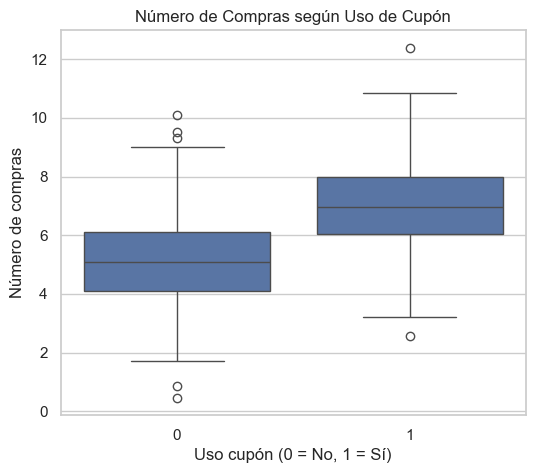

In [64]:
plt.figure(figsize=(6,5))
sns.boxplot(x="uso_cupon", y="numero_compras", data=df)
plt.title("Número de Compras según Uso de Cupón")
plt.xlabel("Uso cupón (0 = No, 1 = Sí)")
plt.ylabel("Número de compras")
plt.show()

#### 4.9.2 Uso de Cupón vs Gasto Total (Boxplot)

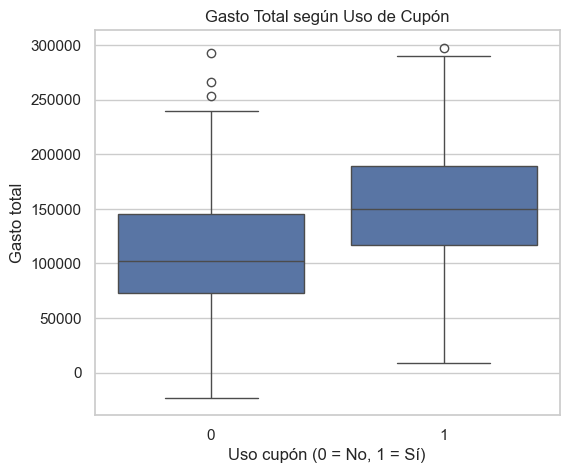

In [65]:
plt.figure(figsize=(6,5))
sns.boxplot(x="uso_cupon", y="gasto_total", data=df)
plt.title("Gasto Total según Uso de Cupón")
plt.xlabel("Uso cupón (0 = No, 1 = Sí)")
plt.ylabel("Gasto total")
plt.show()

### Impacto del uso de cupón

- Los clientes que utilizan cupón presentan una mayor mediana en número de compras en comparación con quienes no lo utilizan.

- Asimismo, el gasto total es significativamente mayor en el grupo que usa cupones, evidenciando que los descuentos no reducen el valor global de compra, sino que parecen incentivar mayor frecuencia y volumen.

- Estos resultados sugieren que el uso de cupones actúa como mecanismo de activación comercial, incrementando tanto la frecuencia como el valor total generado por cliente.

### 4.10 Análisis por Segmento de Cliente

Se analiza si existen diferencias en número de compras y gasto total entre los distintos segmentos de clientes.

#### 4.10.1 Segmento vs Número de Compras (Boxplot)

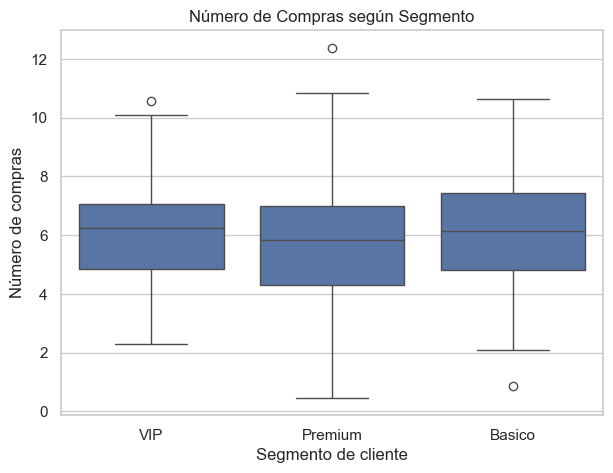

In [66]:
plt.figure(figsize=(7,5))
sns.boxplot(x="segmento_cliente", y="numero_compras", data=df)
plt.title("Número de Compras según Segmento")
plt.xlabel("Segmento de cliente")
plt.ylabel("Número de compras")
plt.show()

#### 4.10.2 Segmento vs Gasto Total (Boxplot)

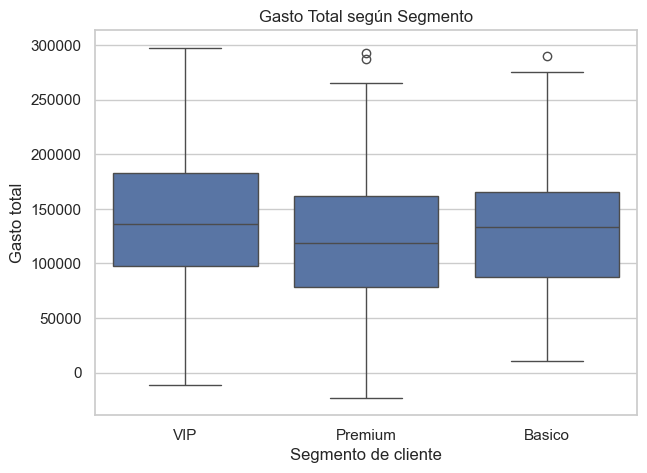

In [67]:
plt.figure(figsize=(7,5))
sns.boxplot(x="segmento_cliente", y="gasto_total", data=df)
plt.title("Gasto Total según Segmento")
plt.xlabel("Segmento de cliente")
plt.ylabel("Gasto total")
plt.show()

### Impacto del segmento de cliente

- No se observan diferencias significativas en el número de compras entre los segmentos VIP, Premium y Básico, ya que las distribuciones presentan alta superposición.

- En términos de gasto total, el segmento VIP muestra una mediana ligeramente superior; sin embargo, la diferencia no es marcadamente significativa respecto a los otros segmentos.

- Estos resultados sugieren que el segmento asignado no es el principal determinante del comportamiento comercial en este dataset, siendo más influyentes variables asociadas al comportamiento digital y al uso de promociones.

### 4.11 Conclusiones Generales del Análisis Exploratorio

A partir del análisis descriptivo, correlacional y comparativo, se identifican los principales factores que influyen en el comportamiento comercial de los clientes.

#### 4.11.1 Conclusiones del EDA

- El gasto_total está fuertemente explicado por el numero_compras (correlación 0.70), indicando que la frecuencia de compra es el principal impulsor del valor generado por cliente.

- Las visitas_mensuales presentan una correlación significativa con numero_compras (0.67) y moderada con gasto_total (0.50), lo que sugiere que la interacción digital impacta directamente en el desempeño comercial.

- El uso de cupones muestra un efecto positivo tanto en número de compras como en gasto total, evidenciando que las promociones actúan como mecanismo de activación y no como reducción de valor.

- Las variables demográficas (edad, ingreso_mensual) presentan baja correlación con las variables comerciales, lo que indica que el comportamiento digital tiene mayor relevancia que las características demográficas en este dataset.

- El segmento_cliente no muestra diferencias marcadas en gasto ni frecuencia de compra, lo que sugiere que la segmentación podría optimizarse utilizando variables de comportamiento en lugar de clasificación estática.

#### 4.11.2 Implicancias estratégicas

- Fomentar estrategias que aumenten visitas_mensuales podría generar incremento indirecto en ventas.
- Las campañas de cupones pueden utilizarse de manera estratégica para estimular consumo sin afectar negativamente el gasto total.
- Se recomienda explorar una segmentación basada en comportamiento (visitas, compras, gasto) en lugar de segmentación declarativa.

### 4.12 Conclusiones del Modelamiento Predictivo

El análisis de regresión lineal simple confirmó que el número de compras es el principal determinante del gasto total, explicando aproximadamente el 48% de su variabilidad (R² ≈ 0.48).

Al incorporar variables adicionales como visitas_mensuales, uso_cupon e ingreso_mensual, el poder explicativo del modelo aumentó de manera marginal (R² ≈ 0.49), lo que indica que estas variables no aportan información significativa adicional para predecir el gasto total.

En particular, ingreso_mensual no resultó estadísticamente significativo, lo que sugiere que, en este dataset, el comportamiento de compra tiene mayor peso que las características económicas declarativas.

Por lo tanto, el modelo más parsimonioso y robusto es aquel centrado en numero_compras como variable clave de explicación del gasto.